<a href="https://colab.research.google.com/github/25730018/colab-notebooks/blob/main/%E6%94%B9%E8%A8%82%E7%89%881_%E5%AD%A4%E7%AB%8B%E8%AA%9E%E8%A4%87%E6%95%B0transformer_encoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Download dataset and modules

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!wget https://github.com/takayama-rado/trado_samples/archive/refs/tags/v0.1.zip -O master.zip

--2026-05-13 04:48:19--  https://github.com/takayama-rado/trado_samples/archive/refs/tags/v0.1.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/takayama-rado/trado_samples/zip/refs/tags/v0.1 [following]
--2026-05-13 04:48:19--  https://codeload.github.com/takayama-rado/trado_samples/zip/refs/tags/v0.1
Resolving codeload.github.com (codeload.github.com)... 140.82.116.9
Connecting to codeload.github.com (codeload.github.com)|140.82.116.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [           <=>      ]  76.21M  19.3MB/s    in 3.9s    

2026-05-13 04:48:23 (19.3 MB/s) - ‘master.zip’ saved [79911353]



In [ ]:
!unzip -o master.zip -d master

Archive:  master.zip
42828d93e2b329808652bd8daf3aa7d190645e45
   creating: master/trado_samples-0.1/
  inflating: master/trado_samples-0.1/.gitignore  
  inflating: master/trado_samples-0.1/LICENSE  
  inflating: master/trado_samples-0.1/README.md  
   creating: master/trado_samples-0.1/colab_files/
 extracting: master/trado_samples-0.1/colab_files/.gitkeep  
  inflating: master/trado_samples-0.1/colab_files/exp_affine_np_einsum.ipynb  
  inflating: master/trado_samples-0.1/colab_files/exp_jax_static.ipynb  
  inflating: master/trado_samples-0.1/colab_files/exp_mpholistic_0.ipynb  
  inflating: master/trado_samples-0.1/colab_files/exp_mpothers_0.ipynb  
  inflating: master/trado_samples-0.1/colab_files/exp_track_affine_jax.ipynb  
  inflating: master/trado_samples-0.1/colab_files/exp_track_affine_numpy.ipynb  
  inflating: master/trado_samples-0.1/colab_files/exp_track_affine_tensorflow.ipynb  
  inflating: master/trado_samples-0.1/colab_files/exp_track_affine_torch.ipynb  
  inflating

In [ ]:
!mv master/trado_samples-0.1/src/modules_gislr .

In [ ]:
!ls

drive  master  master.zip  modules_gislr  sample_data


# 2. Load library

In [ ]:
import glob
import random
import h5py
import copy
import json
import math
import os
import re
import sys
import time
import pandas as pd
from copy import deepcopy
from functools import partial
from inspect import signature
from pathlib import Path
from scipy import signal
from torch.optim.lr_scheduler import ReduceLROnPlateau
from typing import (
    Any,
    Dict
)

# Third party's modules
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import (
    DataLoader)

from torchvision.transforms import Compose

# Local modules
sys.path.append("modules_gislr")
from modules_gislr.dataset import (
    HDF5Dataset,
    merge_padded_batch)
from modules_gislr.defines import (
    get_fullbody_landmarks
)
from modules_gislr.layers import (
    Identity,
    GPoolRecognitionHead,
)
from modules_gislr.train_functions import (
    test_loop,
    val_loop,
    train_loop
)
from modules_gislr.transforms import (
    PartsBasedNormalization,
    ReplaceNan,
    SelectLandmarksAndFeature,
    ToTensor
)

In [ ]:
# 1.生データ用の正規化
class NormalizeRawData:
  def __call__(self, data):
      max_val = np.max(np.abs(data))
      if max_val > 0:
        data = data / max_val
      return data

# 2. 生データ用の振幅変換（範囲を指定可能に）
def raw_amplitude_scaling(data, scale_range=[0.7, 1.3]):
    scale_factor = np.random.uniform(*scale_range)
    return data * scale_factor

# 3. 生データ用の時間伸縮（範囲を指定可能にし、returnを追加）
def raw_time_stretch(data, stretch_range=[0.7, 1.3]):
    stretch_factor = np.random.uniform(*stretch_range)
    old_indices = np.arange(len(data))
    new_length = int(len(data) * stretch_factor)

    # 修正：np.linspace を使用
    new_indices = np.linspace(0, len(data) - 1, new_length)
    stretched_data = np.interp(new_indices, old_indices, data)

    return stretched_data # 戻り値を追加

In [ ]:
# 定数の設定
min=0
#max_n=4000
#max_n=6000
max_n=8000
N=max_n-min
sf=4000

nperseg=128
noverlap=64
Sn=60

#n_all = 30
#
## サンプル分割数
#n_train = 24
#n_val = 3
#n_test = 3

n_all = 1

# サンプル分割数
n_train = 1
n_val = 0
n_test = 0

#name = ['ame', 'asa', 'ie', 'inu', 'kame', 'kasa', 'kumo', 'kutu', 'suna', 'usi',
#        'ohayou', 'tadaima', 'okaeri', 'oyasumi', 'ganbare', 'motiron', 'naruhodo', 'uresii', 'oisii', 'mosimosi']
name = ['hutuu']

# ======== 複数パス ========
#paths = [
#    'drive/MyDrive/suzuki_Data/suzuki/2345文字コマンド/',
#    'drive/MyDrive/Dara_2024/hishigae/2024-12-13/emg2024-12-13-13-47-19/',
#    'drive/MyDrive/Dara_2024/nasu/2024-12-25/emg2024-12-25-15-39-51/',
#    'drive/MyDrive/Dara_2024/sakata/2024-12-25/emg2024-12-25-15-02-47/',
#    'drive/MyDrive/Dara_2024/sakataka/2024-12-10/emg2024-12-10-16-33-36'
#]

paths = 'drive/MyDrive/suzuki_Data/suzuki/2025-07-17/emg2025-07-17-15-53-59/'
# ======== 保存先 ========
dataset_dir = Path("dataset_top10")
dataset_dir.mkdir(parents=True, exist_ok=True)

word_to_index = {word: idx for idx, word in enumerate(name)}
with open(dataset_dir / "dictionary.json", "w", encoding="utf-8") as f:
    json.dump(word_to_index, f, indent=4, ensure_ascii=False)
print("✅ 辞書ファイルを保存しました")

# ======== HDF5 ========
split_hdf5_files = {
    "train": h5py.File(dataset_dir / "0.hdf5", "w"),
    "val": h5py.File(dataset_dir / "1.hdf5", "w"),
    "test": h5py.File(dataset_dir / "2.hdf5", "w"),
}

# ======== 書き込み関数 ========
def process_and_save(file_list, hdf5_file, word, prefix, start_idx=0, augment=False):
    """
    file_list: 読み込むCSVのリスト
    hdf5_file: 保存先のHDF5ファイルオブジェクト
    word: 単語名
    prefix: 保存時の名前の接頭辞
    start_idx: ファイルの連番管理用
    """
    sample_count = 0
    for file in file_list:
        df = pd.read_csv(file, skiprows=13, header=None)

        # 1. 基本データの取得
        raw1 = df[min:max_n][0].values
        raw2 = df[min:max_n][1].values
        raw3 = df[min:max_n][2].values

        if augment:
            # 学習用：5パターンに増強
            variations = [
                (raw1, raw2, raw3), # 1. オリジナル
                # 2. 振幅減衰 (0.8 - 1.0)
                (raw_amplitude_scaling(raw1, [0.7, 1.0]),
                 raw_amplitude_scaling(raw2, [0.7, 1.0]),
                 raw_amplitude_scaling(raw3, [0.7, 1.0])),
                # 3. 振幅増幅 (1.0 - 1.2)
                (raw_amplitude_scaling(raw1, [1.0, 1.3]),
                 raw_amplitude_scaling(raw2, [1.0, 1.3]),
                 raw_amplitude_scaling(raw3, [1.0, 1.3])),
                # 4. 時間短縮 (0.8 - 1.0)
                (raw_time_stretch(raw1, [0.7, 1.0]),
                 raw_time_stretch(raw2, [0.7, 1.0]),
                 raw_time_stretch(raw3, [0.7, 1.0])),
                # 5. 時間伸長 (1.0 - 1.2)
                (raw_time_stretch(raw1, [1.0, 1.3]),
                 raw_time_stretch(raw2, [1.0, 1.3]),
                 raw_time_stretch(raw3, [1.0, 1.3]))
            ]
        else:
            # 検証・テスト用：1パターンのみ
            variations = [(raw1, raw2, raw3)]

        for v1, v2, v3 in variations:
            # --- 前処理 (パディング/スペクトログラム変換) ---
            stretch_max_n = 1.3
            original_len = max_n - min
            expected_len = int(original_len * stretch_max_n)

            def adjust_length(d, length):
                if len(d) > length: return d[:length]
                else: return np.pad(d, (0, length - len(d)), mode='constant')

            data1, data2, data3 = adjust_length(v1, expected_len), adjust_length(v2, expected_len), adjust_length(v3, expected_len)

            _, _, Sxx1 = signal.spectrogram(data1, sf, nperseg=nperseg, noverlap=noverlap, window='hann')
            _, _, Sxx2 = signal.spectrogram(data2, sf, nperseg=nperseg, noverlap=noverlap, window='hann')
            _, _, Sxx3 = signal.spectrogram(data3, sf, nperseg=nperseg, noverlap=noverlap, window='hann')

            Sxx = np.stack([Sxx1[0:Sn].T, Sxx2[0:Sn].T, Sxx3[0:Sn].T], axis=0)
            final = 24 * np.log(np.clip(Sxx, a_min=1e-10, a_max=None))

            # --- 保存 ---
            # ファイル名に sample_count を含めて重複を避ける
            sample_name = f"{prefix}{word}_{sample_count}"
            group = hdf5_file.create_group(sample_name)
            group.create_dataset("feature", data=final)
            group.create_dataset("token", data=np.array([word_to_index[word]], dtype=np.int64))

            sample_count += 1

    return sample_count

# ======== メインループ ========
for path in paths:
    print(f"🔍 Processing path: {path}")
    path_prefix = Path(path).stem + "_"

    for word in name:
        file_list = glob.glob(str(Path(path) / word / '*.csv'))
        random.shuffle(file_list)

        # 1. まず「ファイル単位」で分割する
        # 元のCSVを train(24個), val(3個), test(3個) に分ける
        train_files = file_list[:n_train]
        val_files = file_list[n_train:n_train + n_val]
        test_files = file_list[n_train + n_val:n_train + n_val + n_test]

        # 2. 分割した各グループに対してデータ拡張を適用して保存
        c_train = process_and_save(train_files, split_hdf5_files["train"], word, path_prefix, augment=True)
        c_val = process_and_save(val_files, split_hdf5_files["val"], word, path_prefix, augment=False)
        c_test = process_and_save(test_files, split_hdf5_files["test"], word, path_prefix, augment=False)

        print(f"✅ {word}: Train={c_train}, Val={c_val}, Test={c_test} (samples)")

# ======== クローズ ========
for f in split_hdf5_files.values():
    f.close()
print("✅ 全パスの分割と保存が完了しました。")

✅ 辞書ファイルを保存しました
🔍 Processing path: d
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: r
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: i
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: v
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: e
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: /
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: M
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: y
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: D
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: r
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: i
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: v
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: e
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: /
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: s
✅ hutuu: Train=0, Val=0, Test=0 (samples)
🔍 Processing path: u
✅ hutuu: Train=0, 

In [ ]:
import matplotlib.pyplot as plt

def visualize_augmentations_multi_ch(paths, word='ohayou'):
    # 1. サンプルファイルの読み込み
    file_list = glob.glob(str(Path(paths[0]) / word / '*.csv'))
    if not file_list:
        print("ファイルが見つかりません。")
        return

    # 3チャンネル分（0〜2列目）を読み込み
    df = pd.read_csv(file_list[0], skiprows=13, header=None)
    # min, max_n は環境に合わせて調整済み
    raw_data = df.iloc[min:max_n, 0:3].values

    # 2. 定義した拡張の設定
    aug_configs = [
        ("Original", None, None),
        ("Amp Scale (0.7-1.0)", raw_amplitude_scaling, [0.7, 1.0]),
        ("Amp Scale (1.0-1.3)", raw_amplitude_scaling, [1.0, 1.3]),
        ("Time Stretch (0.7-1.0)", raw_time_stretch, [0.7, 1.0]),
        ("Time Stretch (1.0-1.3)", raw_time_stretch, [1.0, 1.3])
    ]

    # 3. プロットの設定 (5行3列)
    fig, axes = plt.subplots(5, 3, figsize=(15, 18), constrained_layout=True)
    fig.suptitle(f"Augmentation Preview: {word} (All Channels)", fontsize=18, fontweight='bold')

    colors = ['red', 'blue', 'green']
    ch_labels = ['ch1', 'ch2', 'ch3']

    for i, (aug_label, func, r) in enumerate(aug_configs):
        # 拡張処理の適用
        if func is None:
            display_data = raw_data
        else:
            # 各チャンネルに個別に適用（長さが変わる可能性がある）
            augmented_channels = [func(raw_data[:, c], r) for c in range(3)]

            # 最大長を取得
            max_len = max(len(c) for c in augmented_channels)

            # 一番長いコードに合わせて足りないところを0にする（パディング）
            padded_channels = []
            for ch in augmented_channels:
                if len(ch) < max_len:
                    ch = np.pad(ch, (0, max_len - len(ch)), mode='constant')
                padded_channels.append(ch)

            display_data = np.column_stack(padded_channels)

        for j in range(3):
            ax = axes[i, j]
            ax.plot(display_data[:, j], color=colors[j], linewidth=0.6)

            # 左端のグラフに拡張名を、上端のグラフにチャンネル名を表示
            if j == 0:
                ax.set_ylabel(aug_label, fontsize=12, fontweight='bold')
            if i == 0:
                ax.set_title(ch_labels[j], fontsize=12)

            # 軸の共通設定
            ax.set_ylim(-0.30, 0.30) # 振幅を固定
            ax.set_xlim(0, 8000) # 時間を固定
            ax.grid(alpha=0.3)

    plt.show()

# 実行
visualize_augmentations_multi_ch(paths)

ファイルが見つかりません。


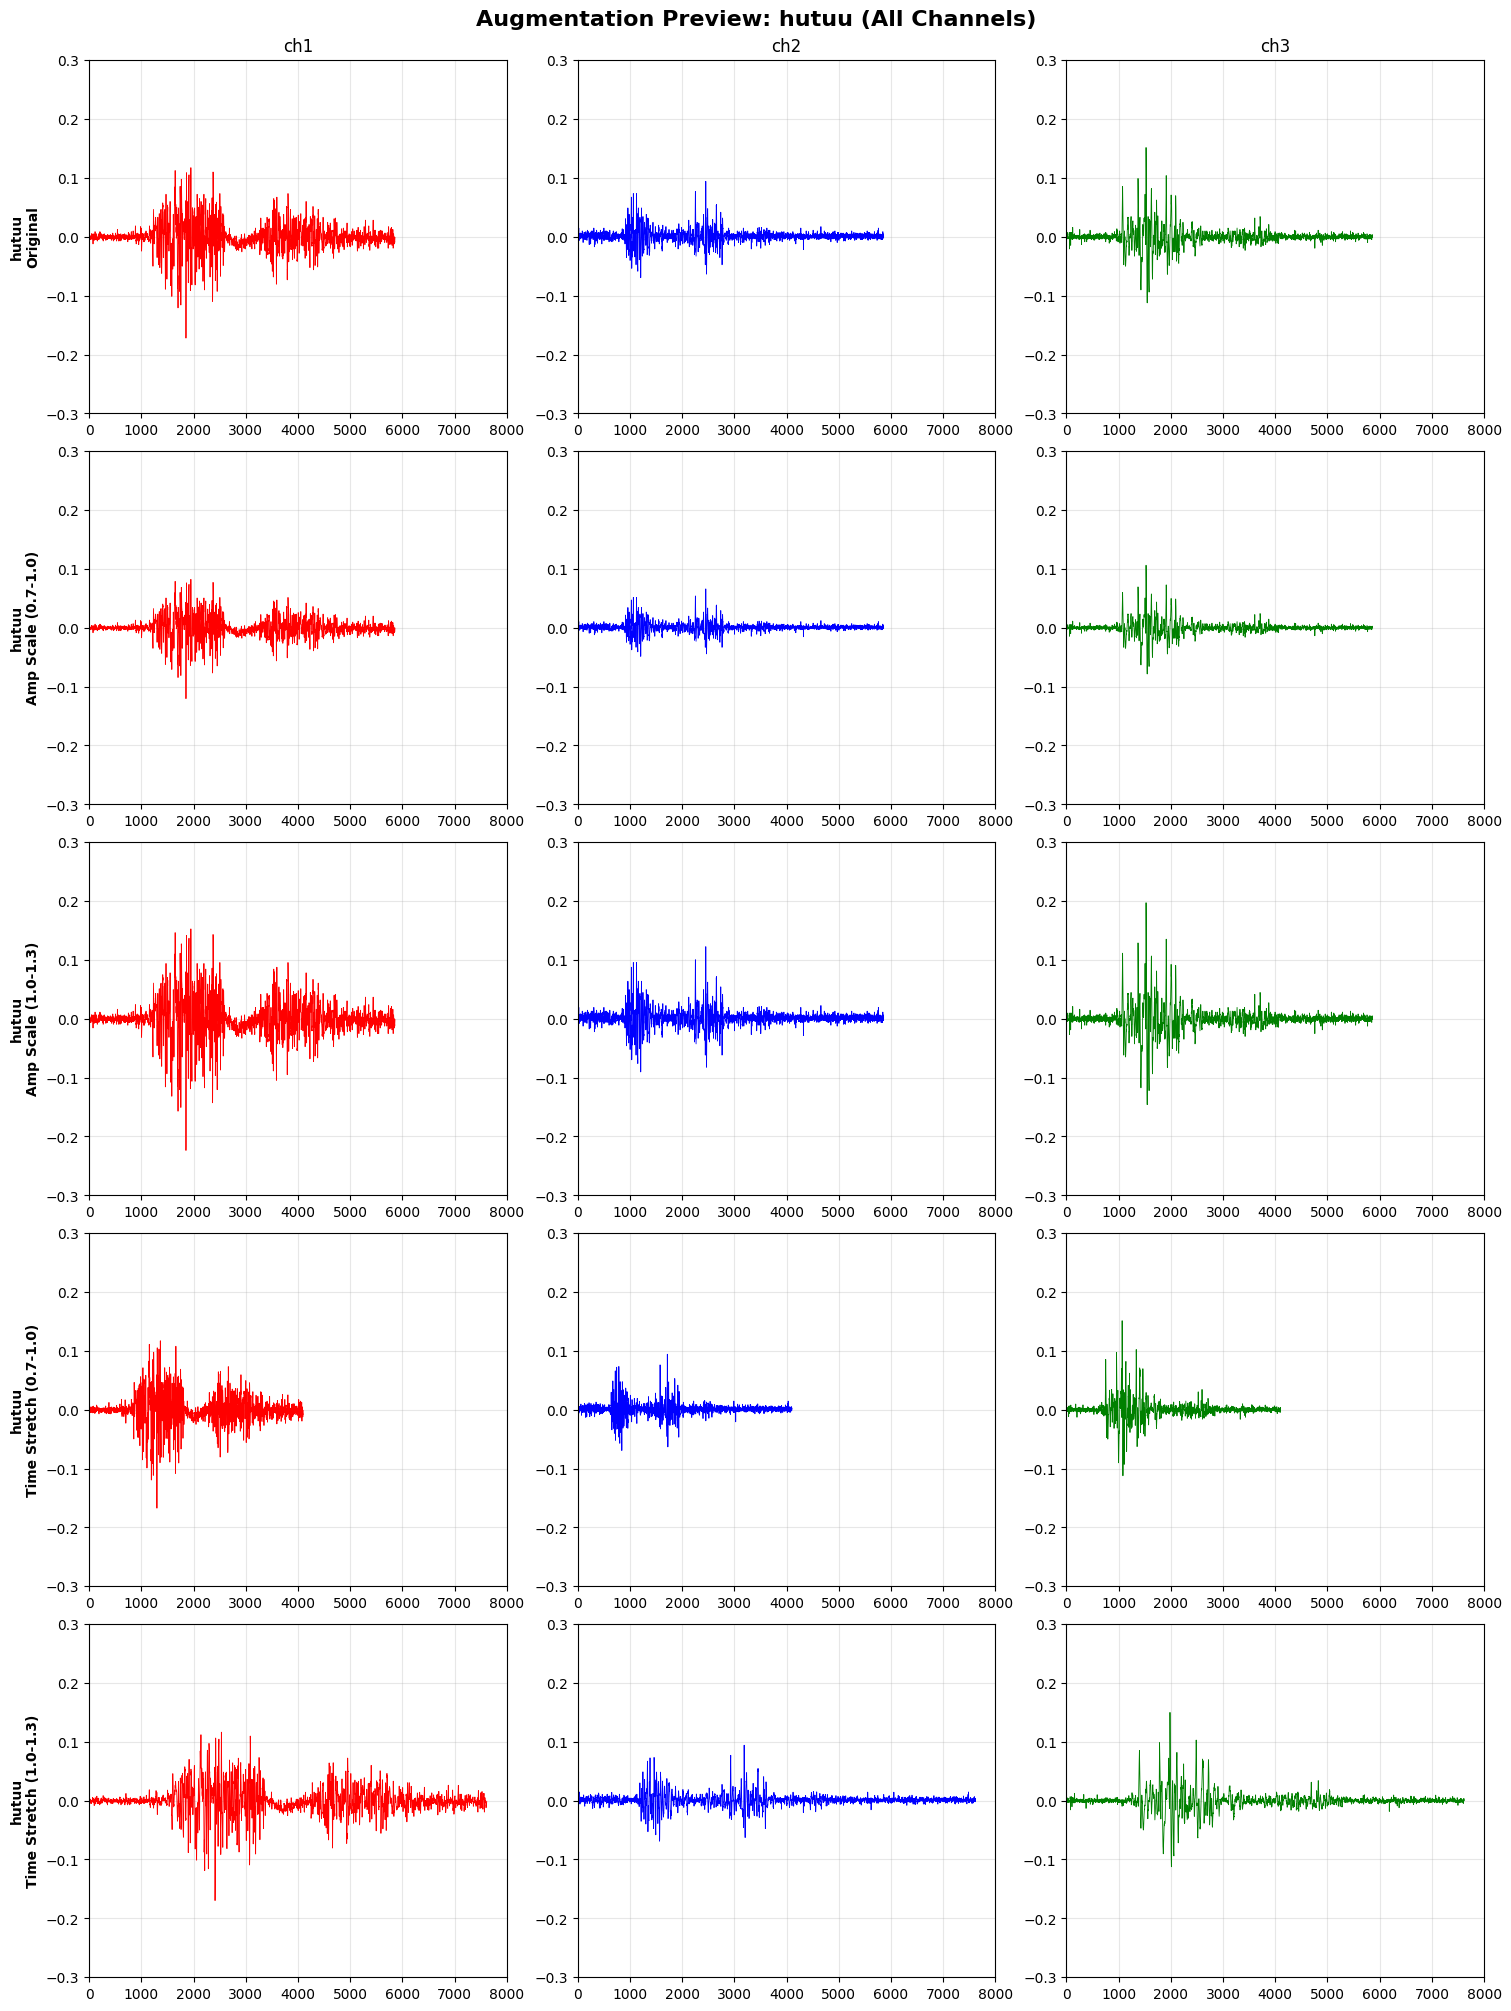

In [ ]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ========== 設定（既存のものと合わせる） ==========
min1 = 0
max_n = 8000  # Cell 9 の max_n に合わせる

# aug_configs: (行ラベル, 関数, パラメータ) の形式
# ※ raw_amplitude_scaling と raw_time_stretch は Cell 8 で定義済み
aug_configs = [
    ("Original",              None,                  None      ),
    ("Amp Scale (0.7-1.0)",   raw_amplitude_scaling, [0.7, 0.7]),
    ("Amp Scale (1.0-1.3)",   raw_amplitude_scaling, [1.3, 1.3]),
    ("Time Stretch (0.7-1.0)",raw_time_stretch,      [0.7, 0.7]),
    ("Time Stretch (1.0-1.3)",raw_time_stretch,      [1.3, 1.3]),
]

colors    = ['red', 'blue', 'green']
ch_labels = ['ch1', 'ch2', 'ch3']

# ========== 表示したい単語グループ ==========
word_groups = [
    ['hutuu'],
]

for group in word_groups:
    n_words = len(group)
    n_augs  = len(aug_configs)

    fig, axes = plt.subplots(
        n_words * n_augs, 3,
        figsize=(15, 4 * n_words * n_augs),
        constrained_layout=True
    )
    fig.suptitle(
        f"Augmentation Preview: {' / '.join(group)} (All Channels)",
        fontsize=16, fontweight='bold'
    )

    for w_idx, word in enumerate(group):
        # CSV を1つ読み込む
        file_list = glob.glob(str(Path(paths) / word / '*.csv'))
        if not file_list:
            print(f"CSVが見つかりません: {word}")
            for a_idx in range(n_augs):
                for j in range(3):
                    axes[w_idx * n_augs + a_idx, j].set_visible(False)
            continue

        df = pd.read_csv(file_list[0], skiprows=13, header=None)
        raw_data = df.iloc[min1:max_n, 0:3].values  # shape: (N, 3)

        for a_idx, (aug_label, func, r) in enumerate(aug_configs):
            row = w_idx * n_augs + a_idx  # 実際の行番号

            # 拡張処理
            if func is None:
                display_data = raw_data
            else:
                augmented_channels = [func(raw_data[:, c], r) for c in range(3)]
                max_len = max(len(c) for c in augmented_channels)
                padded = []
                for ch in augmented_channels:
                    if len(ch) < max_len:
                        ch = np.pad(ch, (0, max_len - len(ch)), mode='constant')
                    padded.append(ch)
                display_data = np.column_stack(padded)

            for j in range(3):
                ax = axes[row, j]
                ax.plot(display_data[:, j], color=colors[j], linewidth=0.6)
                ax.set_ylim(-0.30, 0.30)
                ax.set_xlim(0, 8000)
                ax.grid(alpha=0.3)

                # 左端に「単語名 + 拡張名」を表示
                if j == 0:
                    ax.set_ylabel(f"{word}\n{aug_label}", fontsize=10, fontweight='bold')
                # 一番上の行にチャンネル名を表示
                if row == 0:
                    ax.set_title(ch_labels[j], fontsize=12)

    plt.show()

In [ ]:
!cat dataset_top10/dictionary.json

{
    "ame": 0,
    "asa": 1,
    "ie": 2,
    "inu": 3,
    "kame": 4,
    "kasa": 5,
    "kumo": 6,
    "kutu": 7,
    "suna": 8,
    "usi": 9,
    "ohayou": 10,
    "tadaima": 11,
    "okaeri": 12,
    "oyasumi": 13,
    "ganbare": 14,
    "motiron": 15,
    "naruhodo": 16,
    "uresii": 17,
    "oisii": 18,
    "mosimosi": 19
}

In [ ]:
import h5py
with h5py.File("dataset_top10/0.hdf5", "r") as fread:
    keys = list(fread.keys())
    print(keys)
    group = fread[keys[0]]
    print(group.keys())
    feature = group["feature"][:]
    token = group["token"][:]
    print(feature.shape)
    print(token)

['2345文字コマンド_ame_0', '2345文字コマンド_ame_1', '2345文字コマンド_ame_10', '2345文字コマンド_ame_100', '2345文字コマンド_ame_101', '2345文字コマンド_ame_102', '2345文字コマンド_ame_103', '2345文字コマンド_ame_104', '2345文字コマンド_ame_105', '2345文字コマンド_ame_106', '2345文字コマンド_ame_107', '2345文字コマンド_ame_108', '2345文字コマンド_ame_109', '2345文字コマンド_ame_11', '2345文字コマンド_ame_110', '2345文字コマンド_ame_111', '2345文字コマンド_ame_112', '2345文字コマンド_ame_113', '2345文字コマンド_ame_114', '2345文字コマンド_ame_115', '2345文字コマンド_ame_116', '2345文字コマンド_ame_117', '2345文字コマンド_ame_118', '2345文字コマンド_ame_119', '2345文字コマンド_ame_12', '2345文字コマンド_ame_13', '2345文字コマンド_ame_14', '2345文字コマンド_ame_15', '2345文字コマンド_ame_16', '2345文字コマンド_ame_17', '2345文字コマンド_ame_18', '2345文字コマンド_ame_19', '2345文字コマンド_ame_2', '2345文字コマンド_ame_20', '2345文字コマンド_ame_21', '2345文字コマンド_ame_22', '2345文字コマンド_ame_23', '2345文字コマンド_ame_24', '2345文字コマンド_ame_25', '2345文字コマンド_ame_26', '2345文字コマンド_ame_27', '2345文字コマンド_ame_28', '2345文字コマンド_ame_29', '2345文字コマンド_ame_3', '2345文字コマンド_ame_30', '2345文字コマンド_ame_31', '2345文字コマンド_ame_3

# 3. Implement Transformer ISLR model (Encoder only)

## Positional encoding

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self,
                 dim_model: int,
                 dropout: float,
                 max_len: int = 5000):
        super().__init__()
        self.dim_model = dim_model
        # Compute the positional encodings once in log space.
        pose = torch.zeros(max_len, dim_model, dtype=torch.float32)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, dim_model, 2).float()
                             * -(math.log(10000.0) / dim_model))
        pose[:, 0::2] = torch.sin(position * div_term)
        pose[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pose", pose)

        self.dropout = nn.Dropout(p=dropout)

    def forward(self,
                feature):
        feature = feature + self.pose[None, :feature.shape[1], :]
        feature = self.dropout(feature)
        return feature

### Multi-head attention

In [ ]:
class MultiheadAttention(nn.Module):
    """Multi-headed attention (MHA) layer.

    # Args:
      - key_dim: The dimension of key.
      - query_dim: The dimension of query.
      - att_dim: The dimension of attention space.
      - out_dim: The dimension of output.
      - num_heads: The number of heads.
      - dropout: The dropout probability for attention weights.
      - add_bias: If True, use bias term in linear layers.
    """
    def __init__(self,
                 key_dim,
                 query_dim,
                 att_dim,
                 out_dim,
                 num_heads,
                 dropout,
                 add_bias):
        super().__init__()

        assert att_dim % num_heads == 0
        self.head_dim = att_dim // num_heads
        self.num_heads = num_heads
        self.scale = math.sqrt(self.head_dim)

        self.w_key = nn.Linear(key_dim, att_dim, bias=add_bias)
        self.w_value = nn.Linear(key_dim, att_dim, bias=add_bias)
        self.w_query = nn.Linear(query_dim, att_dim, bias=add_bias)

        self.w_out = nn.Linear(att_dim, out_dim, bias=add_bias)

        self.dropout_attn = nn.Dropout(p=dropout)

        self.neg_inf = None

    def reset_parameters(self, add_bias):
        """Initialize parameters with Xavier uniform distribution.

        # NOTE: For this initialization, please refer
        https://github.com/pytorch/fairseq/blob/master/fairseq/modules/multihead_attention.py  # pylint: disable=line-too-long

        """
        nn.init.xavier_uniform_(self.w_key.weight, gain=1 / math.sqrt(2))
        nn.init.xavier_uniform_(self.w_value.weight, gain=1 / math.sqrt(2))
        nn.init.xavier_uniform_(self.w_query.weight, gain=1 / math.sqrt(2))
        nn.init.xavier_uniform_(self.w_out.weight)
        if add_bias:
            nn.init.constant_(self.w_key.bias, 0.)
            nn.init.constant_(self.w_value.bias, 0.)
            nn.init.constant_(self.w_query.bias, 0.)
            nn.init.constant_(self.w_out.bias, 0.)

    def forward(self,
                key: torch.Tensor,
                value: torch.Tensor,
                query: torch.Tensor,
                mask: torch.Tensor):
        """Perform forward computation.

        # Args:
          - key: `[N, klen, key_dim]`
          - value: `[N, klen, vdim]`
          - query: `[N, qlen, query_dim]`
          - mask: `[N, qlen, klen]`
        # Returns:
          - cvec: The context vector. `[N, qlen, vdim]`
          - aws: The attention weights. `[N, H, qlen, klen]`
        """
        if self.neg_inf is None:
            self.neg_inf = float(np.finfo(
                torch.tensor(0, dtype=key.dtype).numpy().dtype).min)

        bsize, klen = key.size()[: 2]
        qlen = query.size(1)

        # key: `[N, klen, kdim] -> [N, klen, adim] -> [N, klen, H, adim/H(=hdim)]`
        # value: `[N, klen, vdim] -> [N, klen, adim] -> [N, klen, H, adim/H(=hdim)]`
        # query: `[N, qlen, qdim] -> [N, qlen, adim] -> [N, qlen, H, adim/H(=hdim)]`
        key = self.w_key(key).reshape([bsize, -1, self.num_heads, self.head_dim])
        value = self.w_value(value).reshape([bsize, -1, self.num_heads, self.head_dim])
        query = self.w_query(query).reshape([bsize, -1, self.num_heads, self.head_dim])

        # qk_score: `[N, qlen, H, hdim] x [N, klen, H, hdim] -> [N, qlen, klen, H]`
        qk_score = torch.einsum("bihd,bjhd->bijh", (query, key)) / self.scale

        # Apply mask.
        if mask is not None:
            # `[N, qlen, klen] -> [N, qlen, klen, H]`
            mask = mask.unsqueeze(3).repeat([1, 1, 1, self.num_heads])
            mask_size = (bsize, qlen, klen, self.num_heads)
            assert mask.size() == mask_size, f"{mask.size()}:{mask_size}"
            # Negative infinity should be 0 in softmax.
            qk_score = qk_score.masked_fill_(mask == 0, self.neg_inf)
        # Compute attention weight.
        attw = torch.softmax(qk_score, dim=2)
        attw = self.dropout_attn(attw)

        # cvec: `[N, qlen, klen, H] x [N, qlen, H, hdim] -> [N, qlen, H, hdim]
        # -> [N, qlen, H * hdim]`
        cvec = torch.einsum("bijh,bjhd->bihd", (attw, value))
        cvec = cvec.reshape([bsize, -1, self.num_heads * self.head_dim])
        cvec = self.w_out(cvec)
        # attw: `[N, qlen, klen, H]` -> `[N, H, qlen, klen]`
        attw = attw.permute(0, 3, 1, 2)
        return cvec, attw

### Position-wise feed-forward

In [ ]:
def select_reluwise_activation(activation):
    if activation == "relu":
        layer = torch.nn.ReLU()
    elif activation == "gelu":
        layer = torch.nn.GELU()
    elif activation in ["swish", "silu"]:
        layer = torch.nn.SILU()
    elif activation == "mish":
        layer = torch.nn.Mish()
    else:
        raise NotImplementedError(f"Activation for {activation} is not implemented.")
    return layer

In [ ]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self,
                 dim_model,
                 dim_ffw,
                 dropout,
                 activation,
                 add_bias):
       super().__init__()

       self.w_1 = nn.Linear(dim_model, dim_ffw, bias=add_bias)
       self.w_2 = nn.Linear(dim_ffw, dim_model, bias=add_bias)

       self.dropout = nn.Dropout(p=dropout)

       self.activation = select_reluwise_activation(activation)

    def forward(self, feature):
        feature = self.w_1(feature)
        feature = self.activation(feature)
        feature = self.dropout(feature)
        feature = self.w_2(feature)
        return feature

### Transformer encoder layer

In [ ]:
def make_san_mask(pad_mask,
                  causal_mask):
    """Make self-attention mask.

    # Args:
      - pad_mask: The padding mask. `[N, T]`
      - causal_mask: `[N, T (query), T (key)]`
        The mask for future context. For example, if T = 3, causal_mask
        should be:
        [[1, 0, 0,
         [1, 1, 0,
         [1, 1, 1]]
    # Returns:
      - san_mask: `[N, T (query), T (key)]`
    """
    # xx_mask: `[N, qlen, klen]`
    san_mask = pad_mask.unsqueeze(1).repeat([1, pad_mask.shape[-1], 1])
    if causal_mask is not None:
        san_mask = san_mask & causal_mask
    return san_mask

In [ ]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self,
                 dim_model,
                 num_heads,
                 dim_ffw,
                 dropout,
                 activation,
                 layer_norm_eps,
                 norm_first,
                 add_bias):
        super().__init__()

        self.norm_first = norm_first

        self.self_attn = MultiheadAttention(
            key_dim=dim_model,
            query_dim=dim_model,
            att_dim=dim_model,
            out_dim=dim_model,
            num_heads=num_heads,
            dropout=dropout,
            add_bias=add_bias)

        self.ffw = PositionwiseFeedForward(
            dim_model=dim_model,
            dim_ffw=dim_ffw,
            dropout=dropout,
            activation=activation,
            add_bias=add_bias)

        self.dropout = nn.Dropout(p=dropout)

        # The argument `bias` was added at v2.1.0.
        # So, we check whether LayerNorm has this.
        sig = signature(nn.LayerNorm)
        if "bias" in sig.parameters:
            self.norm1 = nn.LayerNorm(dim_model, eps=layer_norm_eps, bias=add_bias)
            self.norm2 = nn.LayerNorm(dim_model, eps=layer_norm_eps, bias=add_bias)
        else:
            self.norm1 = nn.LayerNorm(dim_model, eps=layer_norm_eps)
            self.norm2 = nn.LayerNorm(dim_model, eps=layer_norm_eps)

        # To store attention weights.
        self.attw = None

    def _forward_prenorm(self,
                         feature,
                         san_mask):
        """Pre-normalization structure.

        For the details, please refer
        https://arxiv.org/pdf/2002.04745v1.pdf
        """
        #################################################
        # self-attention
        #################################################
        # `[N, qlen, dim_model]`
        residual = feature
        feature = self.norm1(feature)
        feature, self.attw = self.self_attn(
            key=feature,
            value=feature,
            query=feature,
            mask=san_mask)
        feature = self.dropout(feature) + residual

        #################################################
        # FFW
        #################################################
        residual = feature
        # `[N, qlen, dim_model]`
        feature = self.norm2(feature)
        feature = self.ffw(feature)
        feature = self.dropout(feature) + residual
        return feature

    def _forward_postnorm(self,
                          feature,
                          san_mask):
        """Post-normalization structure (standard).

        """
        #################################################
        # self-attention
        #################################################
        # `[N, qlen, dim_model]`
        residual = feature
        feature, self.attw = self.self_attn(
            key=feature,
            value=feature,
            query=feature,
            mask=san_mask)
        feature = self.dropout(feature) + residual
        feature = self.norm1(feature)

        #################################################
        # FFW
        #################################################
        residual = feature
        # `[N, qlen, dim_model]`
        feature = self.ffw(feature)
        feature = self.dropout(feature) + residual
        feature = self.norm2(feature)
        return feature

    def forward(self,
                feature,
                causal_mask=None,
                src_key_padding_mask=None):
        bsize, qlen = feature.shape[:2]
        if src_key_padding_mask is not None:
            san_mask = make_san_mask(src_key_padding_mask, causal_mask)
        elif causal_mask is not None:
            san_mask = causal_mask
        else:
            san_mask = None

        if self.norm_first:
            feature = self._forward_prenorm(feature, san_mask)
        else:
            feature = self._forward_postnorm(feature, san_mask)

        return feature

### Transformer encoder block

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self,
                 encoder_layer,
                 num_layers,
                 dim_model,
                 dropout_pe,
                 layer_norm_eps,
                 norm_first,
                 add_bias,
                 add_tailnorm):
        super().__init__()

        self.pos_encoder = PositionalEncoding(dim_model, dropout_pe)
        self.layers = nn.ModuleList([copy.deepcopy(encoder_layer) for _ in range(num_layers)])

        # Add LayerNorm at tail position.
        # This is applied only when norm_first is True because
        # post-normalization structure includes tail-normalization in encoder
        # layers.
        if add_tailnorm and norm_first:
            # The argument `bias` was added at v2.1.0.
            # So, we check whether LayerNorm has this.
            sig = signature(nn.LayerNorm)
            if "bias" in sig.parameters:
                self.norm = nn.LayerNorm(dim_model, eps=layer_norm_eps, bias=add_bias)
            else:
                self.norm = nn.LayerNorm(dim_model, eps=layer_norm_eps)
        else:
            self.norm = Identity()

    def forward(self,
                feature,
                causal_mask,
                src_key_padding_mask):
        feature = self.pos_encoder(feature)
        for layer in self.layers:
            feature = layer(feature,
                            causal_mask,
                            src_key_padding_mask)
        feature = self.norm(feature)
        return feature

### ISLR model

In [ ]:
class TransformerEnISLR(nn.Module):
    def __init__(self,
                 in_channels,
                 inter_channels,
                 out_channels,
                 activation="relu",
                 tren_num_layers=1,
                 tren_num_heads=1,
                 tren_dim_ffw=256,
                 tren_dropout_pe=0.1,
                 tren_dropout=0.1,
                 tren_layer_norm_eps=1e-5,
                 tren_norm_first=True,
                 tren_add_bias=True,
                 tren_add_tailnorm=True):
        super().__init__()

        # Feature extraction.
        self.linear = nn.Linear(in_channels, inter_channels)
        self.activation = select_reluwise_activation(activation)

        # Transformer-Encoder.
        enlayer = TransformerEncoderLayer(
                dim_model=inter_channels,
                num_heads=tren_num_heads,
                dim_ffw=tren_dim_ffw,
                dropout=tren_dropout,
                activation=activation,
                layer_norm_eps=tren_layer_norm_eps,
                norm_first=tren_norm_first,
                add_bias=tren_add_bias)
        self.tr_encoder = TransformerEncoder(
            encoder_layer=enlayer,
            num_layers=tren_num_layers,
            dim_model=inter_channels,
            dropout_pe=tren_dropout_pe,
            layer_norm_eps=tren_layer_norm_eps,
            norm_first=tren_norm_first,
            add_bias=tren_add_bias,
            add_tailnorm=tren_add_tailnorm)

        self.head = GPoolRecognitionHead(inter_channels, out_channels)

    def _invert_mask(self, mask):
        _mask = torch.logical_not(mask) if mask is not None else None
        return _mask

    def forward(self,
                feature,
                feature_causal_mask=None,
                feature_pad_mask=None):
        # Feature extraction.
        # `[N, C, T, F] -> [N, T, C, F] -> [N, T, C*F] -> [N, T, C']`
        N, C, T, F = feature.shape
        feature = feature.permute([0, 2, 1, 3])
        feature = feature.reshape(N, T, -1)

        feature = self.linear(feature)
        if torch.isnan(feature).any():
            raise ValueError()
        feature = self.activation(feature)
        if torch.isnan(feature).any():
            raise ValueError()

        # Note:
        # Different from the other layers, the attention of pytorch's
        # Transformer attends to `False` position indicated by the input masks.
        # Therefor, we invert the flags of the input masks here.
        # _feature_causal_mask = self._invert_mask(feature_causal_mask)
        # _feature_pad_mask = self._invert_mask(feature_pad_mask)

        feature = self.tr_encoder(
            feature=feature,
            causal_mask=feature_causal_mask,
            src_key_padding_mask=feature_pad_mask)
        if torch.isnan(feature).any():
            raise ValueError()

        # `[N, T, C] -> [N, C, T]`
        logit = self.head(feature.permute([0, 2, 1]), feature_pad_mask)
        if torch.isnan(feature).any():
            raise ValueError()
        return logit

## Sanity check

In [ ]:
# Access check.
dataset_dir = Path("dataset_top10")
files = list(dataset_dir.iterdir())
dictionary = [fin for fin in files if ".json" in fin.name][0]
hdf5_files = [fin for fin in files if ".hdf5" in fin.name]

print(dictionary)
print(hdf5_files)

dataset_top10/dictionary.json
[PosixPath('dataset_top10/2.hdf5'), PosixPath('dataset_top10/0.hdf5'), PosixPath('dataset_top10/1.hdf5')]


In [ ]:
# Load dictionary.
with open(dictionary, "r") as fread:
    key2token = json.load(fread)

VOCAB = len(key2token)
print(VOCAB)

20


In [ ]:
import torch.nn.functional as F
# 正規化（例：チャネル毎に0-1正規化）
class NormalizeSpectrogram:
    def __call__(self, sample):
        # sample は dict 形式を想定
        feature = sample["feature"]  # [C, T, F]
        max_vals = feature.max(axis=(1, 2), keepdims=True)
        max_vals[max_vals == 0] = 1
        sample["feature"] = feature / max_vals
        return sample

# 振幅スケーリング（発話の強弱）
class RandomAmplitudeScaling_weak(nn.Module):
    def __init__(self, apply_ratio=1.0, scale_range=[0.9, 1.0]):
        super().__init__()
        self.apply_ratio = apply_ratio
        self.scale_range = scale_range

    def forward(self, sample):
        feature = sample["feature"]  # [C, T, F]
        if torch.rand(1).item() < self.apply_ratio:
            scale_factor = np.random.uniform(*self.scale_range)
            feature = feature * scale_factor
        sample["feature"] = feature
        return sample

class RandomAmplitudeScaling_strong(nn.Module):
    def __init__(self, apply_ratio=1.0, scale_range=[1.0, 1.1]):
        super().__init__()
        self.apply_ratio = apply_ratio
        self.scale_range = scale_range

    def forward(self, sample):
        feature = sample["feature"]  # [C, T, F]
        if torch.rand(1).item() < self.apply_ratio:
            scale_factor = np.random.uniform(*self.scale_range)
            feature = feature * scale_factor
        sample["feature"] = feature
        return sample

class RandomTimeStretch_slow(nn.Module):
    def __init__(self, apply_ratio=1.0, scale_range=[0.9, 1.0]):
        super().__init__()
        self.apply_ratio = apply_ratio
        self.scale_range = scale_range

    def forward(self, sample):
        feature = sample["feature"]  # [C, T, F]
        if isinstance(feature, np.ndarray):
            feature = torch.from_numpy(feature).float()

        if torch.rand(1).item() < self.apply_ratio:
            scale_factor = np.random.uniform(*self.scale_range)
            C, T, feat_dim = feature.shape

            new_T = int(T * scale_factor)

            # [C, T, F] → [C, F, T]
            feature = feature.permute(0, 2, 1)
            feature = feature.reshape(C * feat_dim, T).unsqueeze(0)  # [1, C*F, T]

            feature_stretched = F.interpolate(feature, size=new_T, mode='linear', align_corners=False)

            feature_stretched = feature_stretched.squeeze(0).reshape(C, feat_dim, new_T)
            feature_stretched = feature_stretched.permute(0, 2, 1)  # [C, new_T, F]

            # 元に戻さないでそのまま渡す
            sample["feature"] = feature_stretched

        return sample


class RandomTimeStretch_fast(nn.Module):
    def __init__(self, apply_ratio=1.0, scale_range=[1.0, 1.1]):
        super().__init__()
        self.apply_ratio = apply_ratio
        self.scale_range = scale_range

    def forward(self, sample):
        feature = sample["feature"]  # [C, T, F]
        if isinstance(feature, np.ndarray):
            feature = torch.from_numpy(feature).float()

        if torch.rand(1).item() < self.apply_ratio:
            scale_factor = np.random.uniform(*self.scale_range)
            C, T, feat_dim = feature.shape

            new_T = int(T * scale_factor)

            feature = feature.permute(0, 2, 1)
            feature = feature.reshape(C * feat_dim, T).unsqueeze(0)

            feature_stretched = F.interpolate(feature, size=new_T, mode='linear', align_corners=False)

            feature_stretched = feature_stretched.squeeze(0).reshape(C, feat_dim, new_T)
            feature_stretched = feature_stretched.permute(0, 2, 1)

            # 元に戻さずにそのまま
            sample["feature"] = feature_stretched

        return sample

class RandomMasking(nn.Module):
    def __init__(self, F=8, T=10, num_freq_masks=2, num_time_masks=2, apply_ratio=1.0):
        super().__init__()
        self.F = F  # 周波数マスクパラメータ（最大幅）
        self.T = T  # 時間マスクパラメータ（最大幅）
        self.num_freq_masks = num_freq_masks  # 周波数マスクの適用回数
        self.num_time_masks = num_time_masks  # 時間マスクの適用回数
        self.apply_ratio = apply_ratio

    def forward(self, sample):
        feature = sample["feature"]  # [C, T, F]
        if isinstance(feature, np.ndarray):
            feature = torch.from_numpy(feature).float()

        if torch.rand(1).item() < self.apply_ratio:
            C, t_len, f_len = feature.shape

            # 周波数マスキングを指定回数ループ
            for _ in range(self.num_freq_masks):
                f = np.random.randint(0, self.F)
                f0 = np.random.randint(0, f_len - f) if f_len > f else 0
                feature[:, :, f0:f0+f] = 0

            # 時間マスキングを指定回数ループ
            for _ in range(self.num_time_masks):
                t = np.random.randint(0, self.T)
                t0 = np.random.randint(0, t_len - t) if t_len > t else 0
                feature[:, t0:t0+t, :] = 0

        sample["feature"] = feature
        return sample

In [ ]:
trans_norm = NormalizeSpectrogram()
trans_amp_weak = RandomAmplitudeScaling_weak()
trans_amp_strong = RandomAmplitudeScaling_strong()
trans_time_slow = RandomTimeStretch_slow()
trans_time_fast = RandomTimeStretch_fast()
trans_masking = RandomMasking(F=8, T=10, num_freq_masks=2, num_time_masks=2, apply_ratio=1.0)


pre_transforms = Compose([
    trans_norm,
])

train_transforms = Compose([
    ToTensor()
])

val_transforms = Compose([
    ToTensor()
])

test_transforms = Compose([
    ToTensor()
])

train_transforms_with_mask = Compose([
    ToTensor(),
    trans_masking
])

print("Time-Frequency Masking を定義しました。")

Time-Frequency Masking を定義しました。


In [ ]:
# --- 1. データ読み込み ---
def load_samples_from_hdf5(files):
    samples = []
    for fpath in files:
        with h5py.File(fpath, "r") as f:
            for key in f:
                feature = f[key]["feature"][:]
                token = f[key]["token"][:]
                samples.append({"feature": feature, "token": token})
    return samples

train_samples = load_samples_from_hdf5(["dataset_top10/0.hdf5"])

# --- 2. データ拡張 ---
augmented_samples = []

# 各サンプルに対して複数の拡張パターンを適用
for sample in train_samples:
    # 1. オリジナル（正規化済み）
    sample_orig = deepcopy(sample)
    augmented_samples.append(sample_orig)

    # 2. 振幅スケーリング (Weak)
    sample_amp_w = deepcopy(sample)
    sample_amp_w = trans_amp_weak(sample_amp_w)
    augmented_samples.append(sample_amp_w)

    # 3. 振幅スケーリング (Strong)
    sample_amp_s = deepcopy(sample)
    sample_amp_s = trans_amp_strong(sample_amp_s)
    augmented_samples.append(sample_amp_s)

    # 4. 時間伸縮 (Slow)
    sample_time_s = deepcopy(sample)
    sample_time_s = trans_time_slow(sample_time_s)
    augmented_samples.append(sample_time_s)

    # 5. 時間伸縮 (Fast)
    sample_time_f = deepcopy(sample)
    sample_time_f = trans_time_fast(sample_time_f)
    augmented_samples.append(sample_time_f)

    # 6. スペクトログラム・マスキング (SpecAugment)
    sample_mask = deepcopy(sample)
    sample_mask = trans_masking(sample_mask)
    augmented_samples.append(sample_mask)

# --- 3. HDF5として保存 ---
with h5py.File("dataset_top10/3.hdf5", "w") as f:
    for i, sample in enumerate(augmented_samples):
        g = f.create_group(str(i))
        g.create_dataset("feature", data=sample["feature"])
        g.create_dataset("token", data=sample["token"])

print(f"拡張完了: 合計 {len(augmented_samples)} サンプルを dataset_top10/3.hdf5 に保存しました。")

In [ ]:
with h5py.File("dataset_top10/3.hdf5", "r") as f:
    sample_count = len(f.keys())  # ファイル内のグループ数をカウント
    print(f"Augmented samples count: {sample_count}")

Augmented samples count: 12000


In [ ]:
batch_size = 2
feature_shape = (3, -1, 60)  # [C=3, T, F=60]
token_shape = (1,)
merge_fn = partial(merge_padded_batch,
                   feature_shape=feature_shape,
                   token_shape=token_shape,
                   feature_padding_val=0.0,
                   token_padding_val=0)

dataset = HDF5Dataset(hdf5_files, pre_transforms=pre_transforms, transforms=train_transforms)

dataloader = DataLoader(dataset, batch_size=batch_size, collate_fn=merge_fn)
try:
    data = next(iter(dataloader))
    feature_origin = data["feature"]

    print(feature_origin.shape)
except Exception as inst:
    print(inst)

torch.Size([2, 3, 120, 60])


In [ ]:
# Define model.
# in_channels: J * C (130*2=260)
#   J: use_landmarks (130)
#   C: use_channels (2)
# out_channels: 10
in_channels = 3 * Sn
inter_channels = 64
out_channels = VOCAB
activation = "relu"
tren_num_layers = 2
tren_num_heads = 2
tren_dim_ffw = 256
tren_dropout_pe = 0.1
tren_dropout = 0.1
tren_layer_norm_eps = 1e-5
tren_norm_first = False
tren_add_bias = True
tren_add_tailnorm = False

model = TransformerEnISLR(in_channels=in_channels,
                          inter_channels=inter_channels,
                          out_channels=out_channels,
                          activation=activation,
                          tren_num_layers=tren_num_layers,
                          tren_num_heads=tren_num_heads,
                          tren_dim_ffw=tren_dim_ffw,
                          tren_dropout_pe=tren_dropout_pe,
                          tren_dropout=tren_dropout,
                          tren_layer_norm_eps=tren_layer_norm_eps,
                          tren_norm_first=tren_norm_first,
                          tren_add_bias=tren_add_bias,
                          tren_add_tailnorm=tren_add_tailnorm)
print(model)

# Sanity check.
logit = model(feature_origin)
print(logit.shape)
attw0 = model.tr_encoder.layers[0].attw.detach().cpu().numpy()
attw1 = model.tr_encoder.layers[0].attw.detach().cpu().numpy()
print(attw0.shape, attw1.shape)

TransformerEnISLR(
  (linear): Linear(in_features=180, out_features=64, bias=True)
  (activation): ReLU()
  (tr_encoder): TransformerEncoder(
    (pos_encoder): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (w_key): Linear(in_features=64, out_features=64, bias=True)
          (w_value): Linear(in_features=64, out_features=64, bias=True)
          (w_query): Linear(in_features=64, out_features=64, bias=True)
          (w_out): Linear(in_features=64, out_features=64, bias=True)
          (dropout_attn): Dropout(p=0.1, inplace=False)
        )
        (ffw): PositionwiseFeedForward(
          (w_1): Linear(in_features=64, out_features=256, bias=True)
          (w_2): Linear(in_features=256, out_features=64, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (activation): ReLU()
        )
        (dropout): Dropout(p=0.1, inp

In [ ]:
# Access check.
dataset_dir = Path("dataset_top10")
files = list(dataset_dir.iterdir())
dictionary = [fin for fin in files if ".json" in fin.name][0]
hdf5_files = [fin for fin in files if ".hdf5" in fin.name]

print(dictionary)
print(hdf5_files)

dataset_top10/dictionary.json
[PosixPath('dataset_top10/2.hdf5'), PosixPath('dataset_top10/0.hdf5'), PosixPath('dataset_top10/3.hdf5'), PosixPath('dataset_top10/1.hdf5')]


# 4. Train and evaluation

## 4.1 Set common parameters.

In [ ]:
# 共通パラメータ設定
batch_size = 32
load_into_ram = True
train_pid = 3
val_pid = 1
test_pid = 2
num_workers = os.cpu_count()
print(f"Using {num_workers} cores for data loading.")
lr = 2e-4
label_smoothing = 0.1

epochs = 50
eval_every_n_epochs = 1
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} for computation.")

train_hdf5files = [fin for fin in hdf5_files if str(train_pid) in fin.name]
val_hdf5files = [fin for fin in hdf5_files if str(val_pid) in fin.name]
test_hdf5files = [fin for fin in hdf5_files if str(test_pid) in fin.name]

Using 2 cores for data loading.
Using cuda for computation.


In [ ]:
# Build dataloaders.
train_dataset = HDF5Dataset(train_hdf5files,
    pre_transforms=pre_transforms, transforms=train_transforms, load_into_ram=load_into_ram)
val_dataset = HDF5Dataset(val_hdf5files,
    pre_transforms=pre_transforms, transforms=val_transforms, load_into_ram=load_into_ram)
test_dataset = HDF5Dataset(test_hdf5files,
    pre_transforms=pre_transforms, transforms=test_transforms, load_into_ram=load_into_ram)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, collate_fn=merge_fn, num_workers=num_workers, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=merge_fn, num_workers=num_workers, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=1, collate_fn=merge_fn, num_workers=num_workers, shuffle=False)

In [ ]:
print(len(train_dataset))  # 学習データの総サンプル数
print(len(val_dataset))    # 検証データの総サンプル数
print(len(test_dataset))   # テストデータの総サンプル数

12000
300
300


## 4.2 Run training process

### Default settings

In [ ]:
tren_norm_first = False
tren_add_tailnorm = False

model_default = TransformerEnISLR(
    in_channels=in_channels,
    inter_channels=inter_channels,
    out_channels=out_channels,
    activation=activation,
    tren_num_layers=tren_num_layers,
    tren_num_heads=tren_num_heads,
    tren_dim_ffw=tren_dim_ffw,
    tren_dropout_pe=tren_dropout_pe,
    tren_dropout=tren_dropout,
    tren_layer_norm_eps=tren_layer_norm_eps,
    tren_norm_first=tren_norm_first,
    tren_add_bias=tren_add_bias,
    tren_add_tailnorm=tren_add_tailnorm)
print(model_default)

loss_fn = nn.CrossEntropyLoss(reduction="mean")
optimizer = torch.optim.Adam(model_default.parameters(), lr=lr)

TransformerEnISLR(
  (linear): Linear(in_features=180, out_features=64, bias=True)
  (activation): ReLU()
  (tr_encoder): TransformerEncoder(
    (pos_encoder): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (w_key): Linear(in_features=64, out_features=64, bias=True)
          (w_value): Linear(in_features=64, out_features=64, bias=True)
          (w_query): Linear(in_features=64, out_features=64, bias=True)
          (w_out): Linear(in_features=64, out_features=64, bias=True)
          (dropout_attn): Dropout(p=0.1, inplace=False)
        )
        (ffw): PositionwiseFeedForward(
          (w_1): Linear(in_features=64, out_features=256, bias=True)
          (w_2): Linear(in_features=256, out_features=64, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (activation): ReLU()
        )
        (dropout): Dropout(p=0.1, inp

In [ ]:
# Train, validation, and evaluation.
model_default.to(device)

train_losses = []
val_losses = []
test_accs = []
print("Start training.")
for epoch in range(epochs):
    print("-" * 80)
    print(f"Epoch {epoch+1}")

    train_losses = train_loop(train_dataloader, model_default, loss_fn, optimizer, device)
    val_loss = val_loop(val_dataloader, model_default, loss_fn, device)
    val_losses.append(val_loss)

    if (epoch+1) % eval_every_n_epochs == 0:
        acc = test_loop(test_dataloader, model_default, device)
        test_accs.append(acc)
train_losses_default = np.array(train_losses)
val_losses_default = np.array(val_losses)
test_accs_default = np.array(test_accs)

print(f"Minimum validation loss:{val_losses_default.min()} at {np.argmin(val_losses_default)+1} epoch.")
print(f"Maximum accuracy:{test_accs_default.max()} at {np.argmax(test_accs_default)*eval_every_n_epochs+1} epoch.")

Start training.
--------------------------------------------------------------------------------
Epoch 1
Start training.
loss:4.440607 [    0/12000]
loss:2.916381 [ 3200/12000]
loss:2.749194 [ 6400/12000]
loss:2.682717 [ 9600/12000]
Done. Time:7.656858929000009
Training performance: 
 Avg loss:2.836411

Start validation.
Done. Time:0.5572170609998466
Validation performance: 
 Avg loss:2.537499

Start evaluation.
Done. Time:2.358031435000157
Test performance: 
 Accuracy:17.7%
--------------------------------------------------------------------------------
Epoch 2
Start training.
loss:2.307651 [    0/12000]
loss:2.153114 [ 3200/12000]
loss:2.309351 [ 6400/12000]
loss:2.045769 [ 9600/12000]
Done. Time:7.6813495559999865
Training performance: 
 Avg loss:2.131906

Start validation.
Done. Time:0.4900825380000242
Validation performance: 
 Avg loss:2.045184

Start evaluation.
Done. Time:2.0194706809998024
Test performance: 
 Accuracy:28.0%
------------------------------------------------------

### Apply pre-layernorm structure

In [ ]:
tren_norm_first = True
tren_add_tailnorm = False

model_pnorm = TransformerEnISLR(
    in_channels=in_channels,
    inter_channels=inter_channels,
    out_channels=out_channels,
    activation=activation,
    tren_num_layers=tren_num_layers,
    tren_num_heads=tren_num_heads,
    tren_dim_ffw=tren_dim_ffw,
    tren_dropout_pe=tren_dropout_pe,
    tren_dropout=tren_dropout,
    tren_layer_norm_eps=tren_layer_norm_eps,
    tren_norm_first=tren_norm_first,
    tren_add_bias=tren_add_bias,
    tren_add_tailnorm=tren_add_tailnorm)
print(model_pnorm)

loss_fn = nn.CrossEntropyLoss(reduction="mean")
optimizer = torch.optim.Adam(model_pnorm.parameters(), lr=lr)

TransformerEnISLR(
  (linear): Linear(in_features=180, out_features=64, bias=True)
  (activation): ReLU()
  (tr_encoder): TransformerEncoder(
    (pos_encoder): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (w_key): Linear(in_features=64, out_features=64, bias=True)
          (w_value): Linear(in_features=64, out_features=64, bias=True)
          (w_query): Linear(in_features=64, out_features=64, bias=True)
          (w_out): Linear(in_features=64, out_features=64, bias=True)
          (dropout_attn): Dropout(p=0.1, inplace=False)
        )
        (ffw): PositionwiseFeedForward(
          (w_1): Linear(in_features=64, out_features=256, bias=True)
          (w_2): Linear(in_features=256, out_features=64, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (activation): ReLU()
        )
        (dropout): Dropout(p=0.1, inp

In [ ]:
# Train, validation, and evaluation.
model_pnorm.to(device)

train_losses = []
val_losses = []
test_accs = []
print("Start training.")
for epoch in range(epochs):
    print("-" * 80)
    print(f"Epoch {epoch+1}")

    train_losses = train_loop(train_dataloader, model_pnorm, loss_fn, optimizer, device)
    val_loss = val_loop(val_dataloader, model_pnorm, loss_fn, device)
    val_losses.append(val_loss)

    if (epoch+1) % eval_every_n_epochs == 0:
        acc = test_loop(test_dataloader, model_pnorm, device)
        test_accs.append(acc)
train_losses_pnorm = np.array(train_losses)
val_losses_pnorm = np.array(val_losses)
test_accs_pnorm = np.array(test_accs)

print(f"Minimum validation loss:{val_losses_pnorm.min()} at {np.argmin(val_losses_pnorm)+1} epoch.")
print(f"Maximum accuracy:{test_accs_pnorm.max()} at {np.argmax(test_accs_pnorm)*eval_every_n_epochs+1} epoch.")

Start training.
--------------------------------------------------------------------------------
Epoch 1
Start training.
loss:4.340856 [    0/12000]
loss:2.804462 [ 3200/12000]
loss:2.482250 [ 6400/12000]
loss:2.476390 [ 9600/12000]
Done. Time:6.839344910999898
Training performance: 
 Avg loss:2.762516

Start validation.
Done. Time:0.7381456920002165
Validation performance: 
 Avg loss:2.308487

Start evaluation.
Done. Time:2.5043512929996723
Test performance: 
 Accuracy:23.3%
--------------------------------------------------------------------------------
Epoch 2
Start training.
loss:2.318027 [    0/12000]
loss:1.958392 [ 3200/12000]
loss:2.072278 [ 6400/12000]
loss:2.253211 [ 9600/12000]
Done. Time:6.800096389999908
Training performance: 
 Avg loss:2.068926

Start validation.
Done. Time:0.48823525900024833
Validation performance: 
 Avg loss:2.055552

Start evaluation.
Done. Time:1.9946911930001079
Test performance: 
 Accuracy:27.0%
-----------------------------------------------------

### Apply pre-layernorm structure with tail layernorm

In [ ]:
tren_norm_first = True
tren_add_tailnorm = True

model_pnorm_tnorm = TransformerEnISLR(
    in_channels=in_channels,
    inter_channels=inter_channels,
    out_channels=out_channels,
    activation=activation,
    tren_num_layers=tren_num_layers,
    tren_num_heads=tren_num_heads,
    tren_dim_ffw=tren_dim_ffw,
    tren_dropout_pe=tren_dropout_pe,
    tren_dropout=tren_dropout,
    tren_layer_norm_eps=tren_layer_norm_eps,
    tren_norm_first=tren_norm_first,
    tren_add_bias=tren_add_bias,
    tren_add_tailnorm=tren_add_tailnorm)
print(model_pnorm_tnorm)

loss_fn = nn.CrossEntropyLoss(reduction="mean")
optimizer = torch.optim.Adam(model_pnorm_tnorm.parameters(), lr=lr)

TransformerEnISLR(
  (linear): Linear(in_features=180, out_features=64, bias=True)
  (activation): ReLU()
  (tr_encoder): TransformerEncoder(
    (pos_encoder): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (w_key): Linear(in_features=64, out_features=64, bias=True)
          (w_value): Linear(in_features=64, out_features=64, bias=True)
          (w_query): Linear(in_features=64, out_features=64, bias=True)
          (w_out): Linear(in_features=64, out_features=64, bias=True)
          (dropout_attn): Dropout(p=0.1, inplace=False)
        )
        (ffw): PositionwiseFeedForward(
          (w_1): Linear(in_features=64, out_features=256, bias=True)
          (w_2): Linear(in_features=256, out_features=64, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (activation): ReLU()
        )
        (dropout): Dropout(p=0.1, inp

In [ ]:
# Train, validation, and evaluation.
model_pnorm_tnorm.to(device)

train_losses = []
val_losses = []
test_accs = []
print("Start training.")
for epoch in range(epochs):
    print("-" * 80)
    print(f"Epoch {epoch+1}")

    train_losses = train_loop(train_dataloader, model_pnorm_tnorm, loss_fn, optimizer, device)
    val_loss = val_loop(val_dataloader, model_pnorm_tnorm, loss_fn, device)
    val_losses.append(val_loss)

    if (epoch+1) % eval_every_n_epochs == 0:
        acc = test_loop(test_dataloader, model_pnorm_tnorm, device)
        test_accs.append(acc)
train_losses_pnorm_tnorm = np.array(train_losses)
val_losses_pnorm_tnorm = np.array(val_losses)
test_accs_pnorm_tnorm = np.array(test_accs)

print(f"Minimum validation loss:{val_losses_pnorm_tnorm.min()} at {np.argmin(val_losses_pnorm_tnorm)+1} epoch.")
print(f"Maximum accuracy:{test_accs_pnorm_tnorm.max()} at {np.argmax(test_accs_pnorm_tnorm)*eval_every_n_epochs+1} epoch.")

Start training.
--------------------------------------------------------------------------------
Epoch 1
Start training.
loss:3.512592 [    0/12000]
loss:2.886490 [ 3200/12000]
loss:2.878741 [ 6400/12000]
loss:2.559780 [ 9600/12000]
Done. Time:7.490280257999984
Training performance: 
 Avg loss:2.807066

Start validation.
Done. Time:0.7818652679998195
Validation performance: 
 Avg loss:2.308639

Start evaluation.
Done. Time:2.3559668320003766
Test performance: 
 Accuracy:20.7%
--------------------------------------------------------------------------------
Epoch 2
Start training.
loss:2.407409 [    0/12000]
loss:2.274588 [ 3200/12000]
loss:2.036573 [ 6400/12000]
loss:2.323341 [ 9600/12000]
Done. Time:6.781946138000421
Training performance: 
 Avg loss:2.075862

Start validation.
Done. Time:0.49874925699987216
Validation performance: 
 Avg loss:2.048825

Start evaluation.
Done. Time:2.154211541999757
Test performance: 
 Accuracy:28.0%
------------------------------------------------------

### Plort result
#### Recognition performance

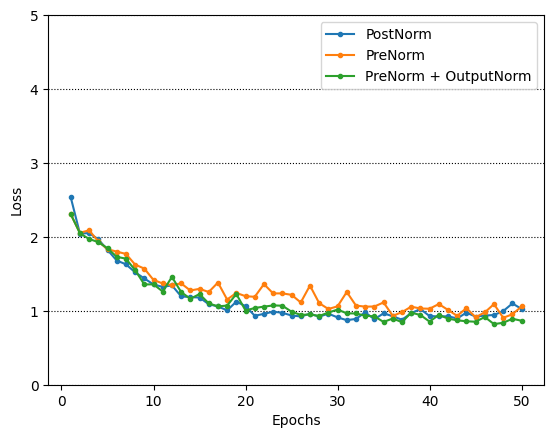

In [ ]:
import matplotlib.pyplot as plt

plt.grid(axis="y", linestyle="dotted", color="k")

xs = np.arange(1, len(val_losses_default)+1)
plt.plot(xs, val_losses_default, label="PostNorm", marker=".")
plt.plot(xs, val_losses_pnorm, label="PreNorm", marker=".")
plt.plot(xs, val_losses_pnorm_tnorm, label="PreNorm + OutputNorm", marker=".")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.ylim([0.0, 5.0])
plt.legend()
plt.show()

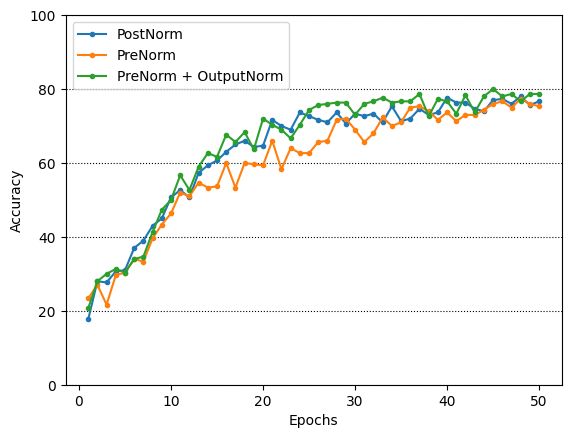

In [ ]:
plt.grid(axis="y", linestyle="dotted", color="k")

xs = np.arange(1, len(test_accs_default)+1)
plt.plot(xs, test_accs_default, label="PostNorm", marker=".")
plt.plot(xs, test_accs_pnorm, label="PreNorm", marker=".")
plt.plot(xs, test_accs_pnorm_tnorm, label="PreNorm + OutputNorm", marker=".")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim([0.0, 100.0])
plt.legend()
plt.show()

#### Attention weights

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_attention(attw0, attw1, true_label, pred_label):
    tlength = attw0.shape[-1]
    norm = mpl.colors.Normalize(vmin=0, vmax=max(attw0.max(), attw1.max()))

    fig, axes = plt.subplots(2, 2, figsize=(10, 10),
                             sharex="col",
                             layout="constrained")

    fig.suptitle(f"Attention Weights - Target: {true_label} (Predicted: {pred_label})", fontsize=16)

    cmap = plt.get_cmap("Blues")

    axes[0, 0].imshow(attw0[0, 0], cmap=cmap)
    axes[0, 1].imshow(attw0[0, 1], cmap=cmap)
    axes[1, 0].imshow(attw1[0, 0], cmap=cmap)
    axes[1, 1].imshow(attw1[0, 1], cmap=cmap)

    axes[0, 0].set_title("Layer0, Head0", loc="center")
    axes[0, 1].set_title("Layer0, Head1", loc="center")
    axes[1, 0].set_title("Layer1, Head0", loc="center")
    axes[1, 1].set_title("Layer1, Head1", loc="center")

    fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes.ravel().tolist(), aspect=20)
    plt.show()

In [ ]:
test_iter = iter(test_dataloader)
data = next(test_iter)
feature = data["feature"]

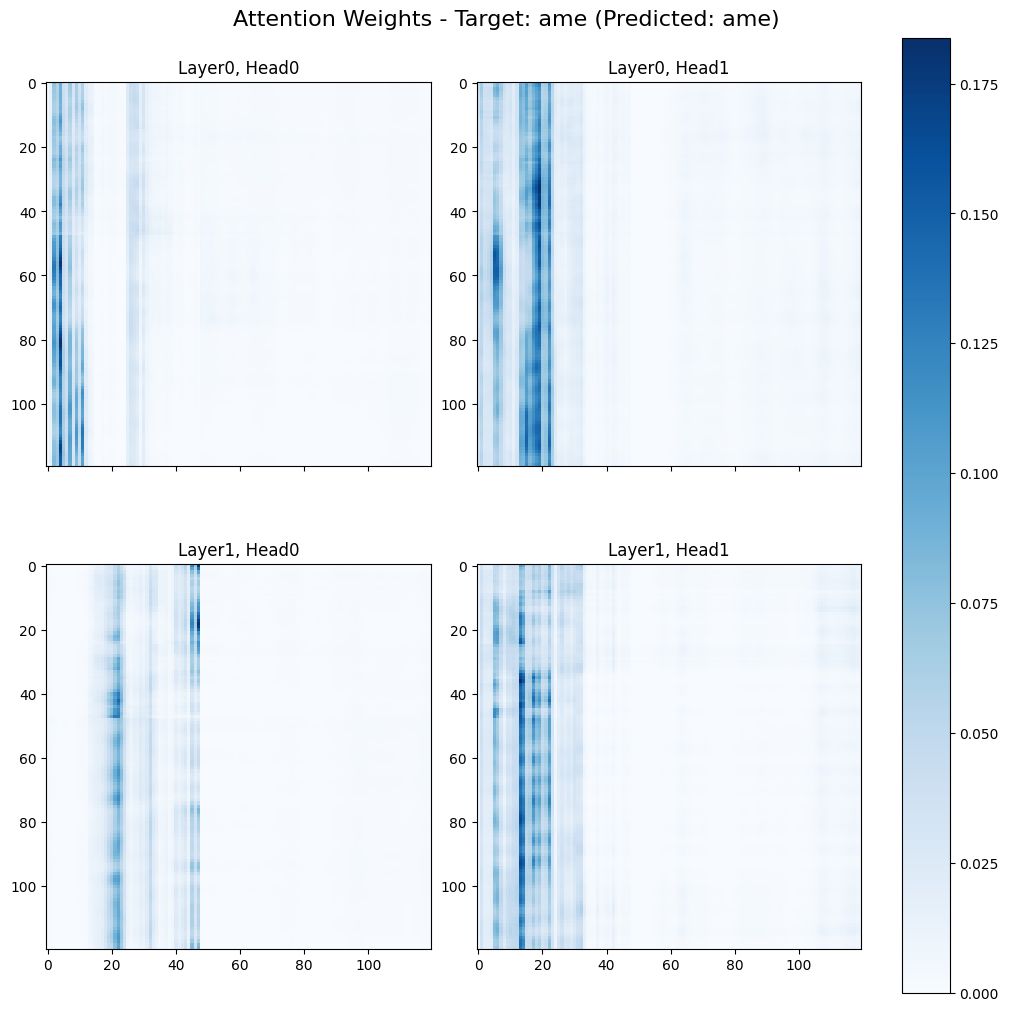

In [ ]:
# テストデータからサンプルを取得して単語名を特定
test_iter = iter(test_dataloader)
data = next(test_iter)
feature = data["feature"]
token = data["token"]

true_word = name[token[0].item()]

# 推論とAttention取得
model_default.eval()
with torch.no_grad():
    logit_default = model_default(feature.to(device))
    pred_default = name[torch.argmax(logit_default, dim=1).item()]
    attw_default_0 = model_default.tr_encoder.layers[0].attw.detach().cpu().numpy()
    attw_default_1 = model_default.tr_encoder.layers[1].attw.detach().cpu().numpy()

plot_attention(attw_default_0, attw_default_1, true_word, pred_default)

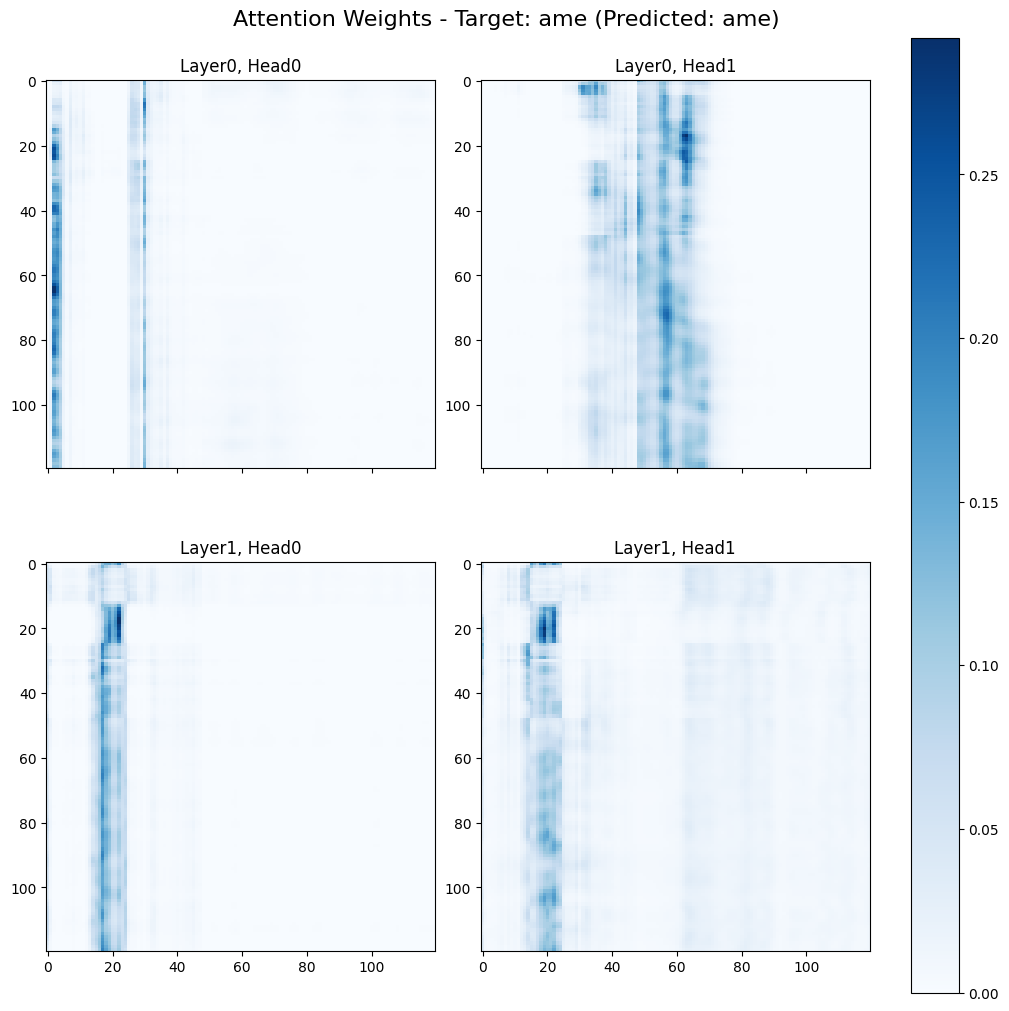

In [ ]:
model_pnorm.eval()
with torch.no_grad():
    # 推論の実行
    logit_pnorm = model_pnorm(feature.to(device))
    # 予測ラベルと正解ラベルの取得
    pred_pnorm = name[torch.argmax(logit_pnorm, dim=1).item()]
    true_word = name[token[0].item()]

    # Attention重みの取得
    attw_pnorm_0 = model_pnorm.tr_encoder.layers[0].attw.detach().cpu().numpy()
    attw_pnorm_1 = model_pnorm.tr_encoder.layers[1].attw.detach().cpu().numpy()

# 修正：引数に true_word と pred_pnorm を追加
plot_attention(attw_pnorm_0, attw_pnorm_1, true_word, pred_pnorm)

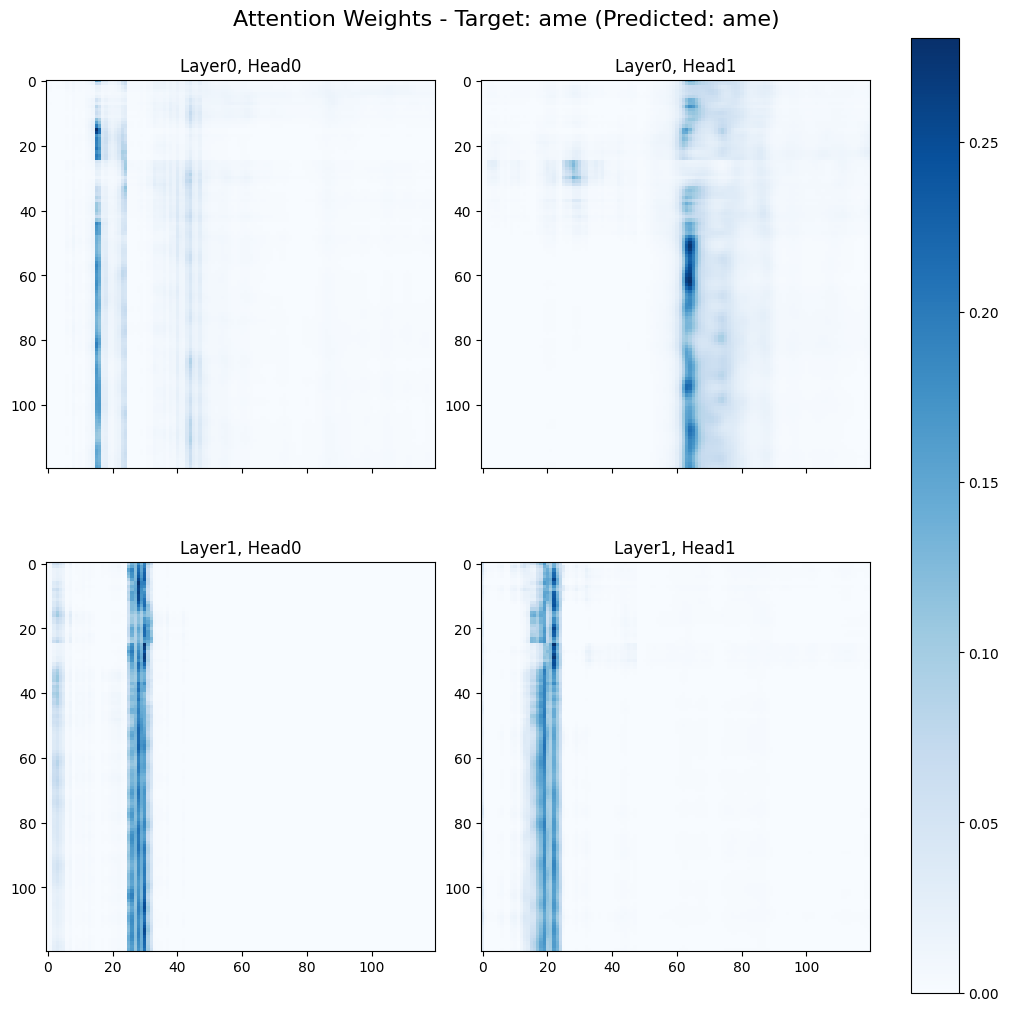

In [ ]:
model_pnorm_tnorm.eval()
with torch.no_grad():
    # 推論の実行
    logit_pnorm_tnorm = model_pnorm_tnorm(feature.to(device))
    # 予測ラベルと正解ラベルの取得
    pred_pnorm_tnorm = name[torch.argmax(logit_pnorm_tnorm, dim=1).item()]
    true_word = name[token[0].item()]

    # Attention重みの取得
    attw_pnorm_tnorm_0 = model_pnorm_tnorm.tr_encoder.layers[0].attw.detach().cpu().numpy()
    attw_pnorm_tnorm_1 = model_pnorm_tnorm.tr_encoder.layers[1].attw.detach().cpu().numpy()

# 修正：引数に true_word と pred_pnorm_tnorm を追加
plot_attention(attw_pnorm_tnorm_0, attw_pnorm_tnorm_1, true_word, pred_pnorm_tnorm)

In [ ]:
print("Feature min:", feature.min().item())
print("Feature max:", feature.max().item())

Feature min: 1.0
Feature max: 2.180509567260742


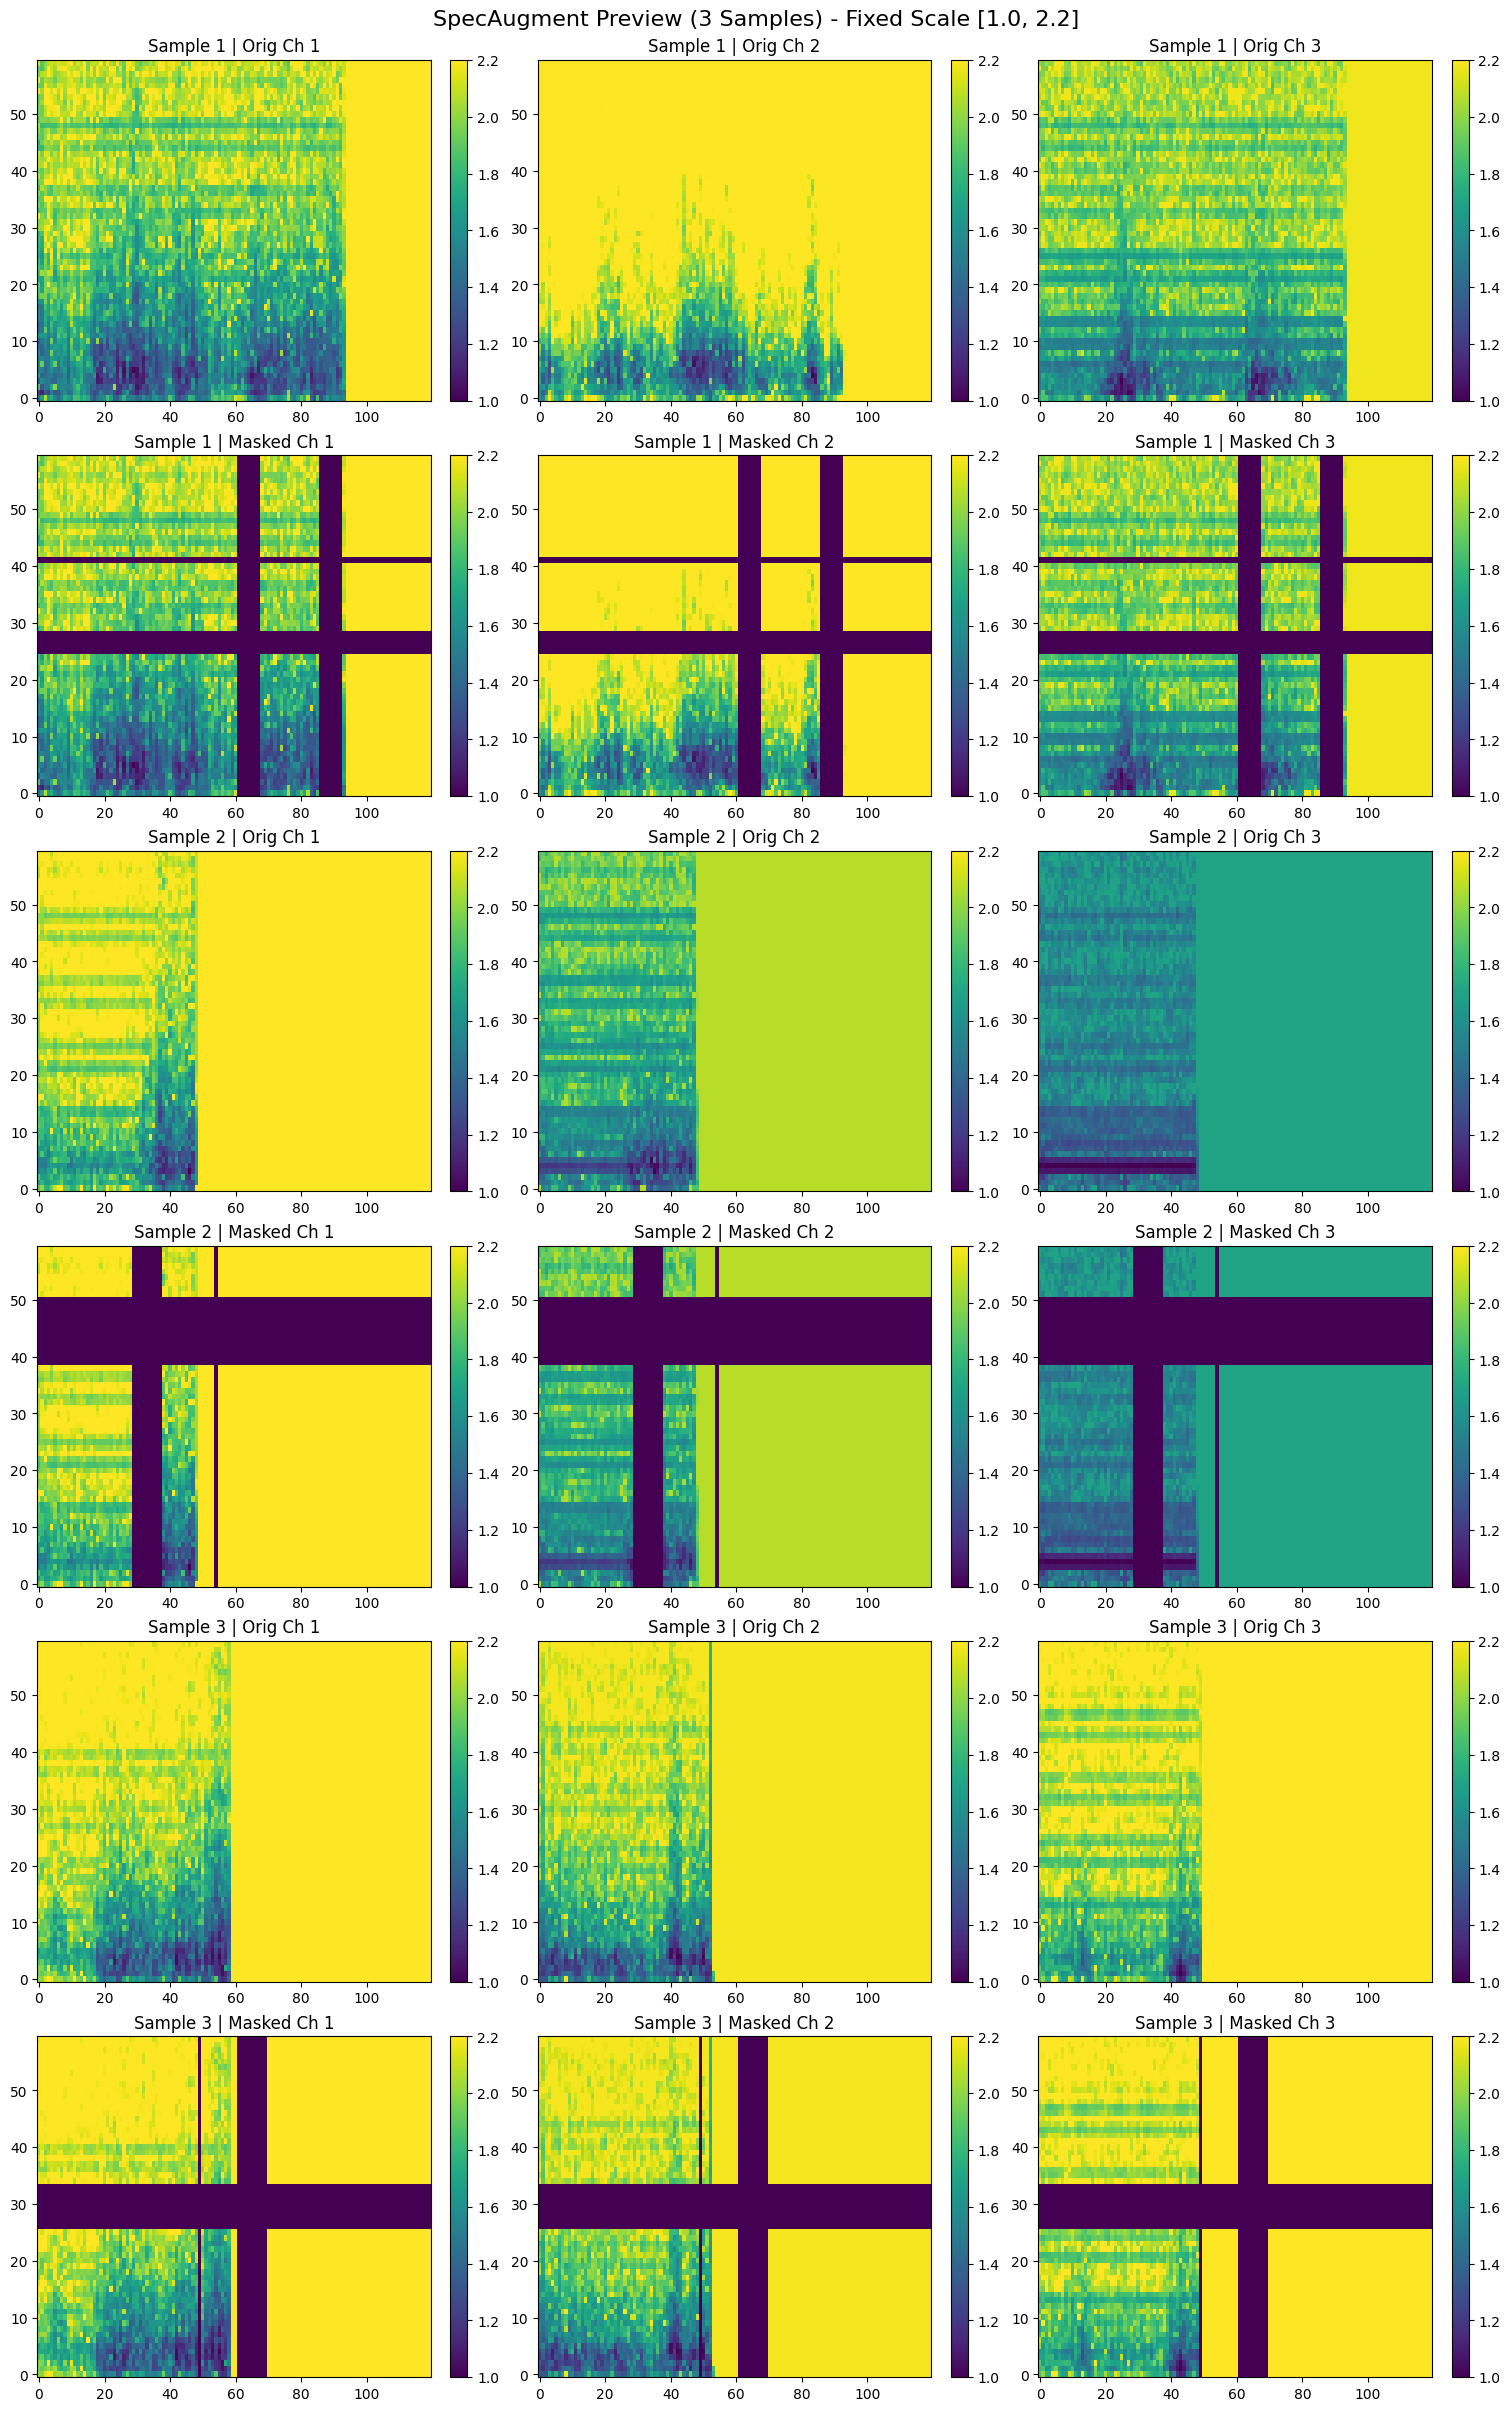

In [ ]:
num_samples = 3  # 表示したいサンプル数

# --- 変更点: カラースケールを固定値で設定 ---
# データの正規化後のレンジに合わせて適宜数値を調整してください。
# （例: 標準化されているなら -3.0 ~ 3.0 など）
V_MIN = 1.0
V_MAX = 2.2

# 1. バッチを取得
data = next(iter(train_dataloader))

# 2. 可視化の設定
fig, axes = plt.subplots(num_samples * 2, 3, figsize=(15, 4 * num_samples * 2), constrained_layout=True)
fig.suptitle(f'SpecAugment Preview (3 Samples) - Fixed Scale [{V_MIN}, {V_MAX}]', fontsize=16)

for s_idx in range(num_samples):
    # 特定のサンプルの特徴量を取得
    original_feature = data['feature'][s_idx].clone()

    # マスキング適用
    sample = {'feature': original_feature.clone()}
    masked_sample = trans_masking(sample)
    masked_feature = masked_sample['feature']

    # 各チャンネルをループ
    for i in range(3):
        row_orig = s_idx * 2
        row_mask = s_idx * 2 + 1

        # Originalの描画
        ax_orig = axes[row_orig, i]
        im_orig = ax_orig.imshow(original_feature[i].T.numpy(),
                                 aspect='auto', origin='lower',
                                 cmap='viridis', vmin=V_MIN, vmax=V_MAX) # ★固定値を適用
        ax_orig.set_title(f'Sample {s_idx+1} | Orig Ch {i+1}')
        fig.colorbar(im_orig, ax=ax_orig)

        # Maskedの描画
        ax_mask = axes[row_mask, i]
        im_mask = ax_mask.imshow(masked_feature[i].T.numpy(),
                                 aspect='auto', origin='lower',
                                 cmap='viridis', vmin=V_MIN, vmax=V_MAX) # ★固定値を適用
        ax_mask.set_title(f'Sample {s_idx+1} | Masked Ch {i+1}')
        fig.colorbar(im_mask, ax=ax_mask)

plt.show()

### 5. Detailed Evaluation and Model Export

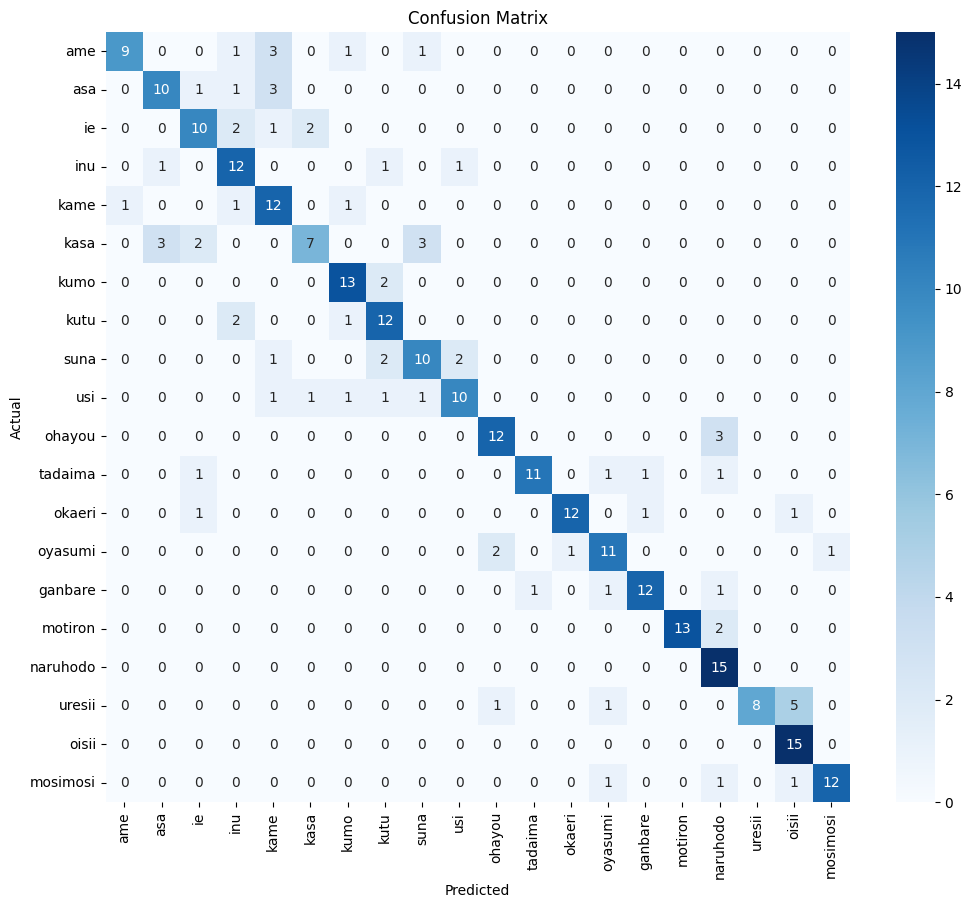

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, dataloader, device, words):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            feature = batch["feature"].to(device)
            token = batch["token"].to(device)
            logits = model(feature)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(token.cpu().numpy().flatten())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=words, yticklabels=words, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

# PreNormモデル（精度が良かったもの）で実行
plot_confusion_matrix(model_pnorm, test_dataloader, device, name)

In [ ]:
# 最良モデルの保存
model_path = dataset_dir / "best_model_pnorm.pth"
torch.save(model_pnorm.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to dataset_top10/best_model_pnorm.pth


### 6. Inference Example

学習したモデルを使って、個別のサンプルに対して推論を行うテストをします。

In [ ]:
def predict(model, feature, device, word_list):
    model.eval()
    with torch.no_grad():
        # feature: [C, T, F]
        feature = feature.unsqueeze(0).to(device) # Add batch dimension -> [1, C, T, F]
        logits = model(feature)
        pred_idx = torch.argmax(logits, dim=1).item()

    return word_list[pred_idx]

# テストデータセットから1つランダムに取得
random_idx = random.randint(0, len(test_dataset) - 1)
sample = test_dataset[random_idx]
feature = sample['feature']
label_idx = sample['token'][0]
true_word = name[label_idx]

# 予測実行
predicted_word = predict(model_pnorm, feature, device, name)

print(f"Sample Index: {random_idx}")
print(f"Correct Label: {true_word}")
print(f"Predicted    : {predicted_word}")

if true_word == predicted_word:
    print("✅ Prediction Successful!")
else:
    print("❌ Prediction Failed.")

Sample Index: 122
Correct Label: ame
Predicted    : kame
❌ Prediction Failed.
